In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [9]:
import matplotlib.pyplot as plt


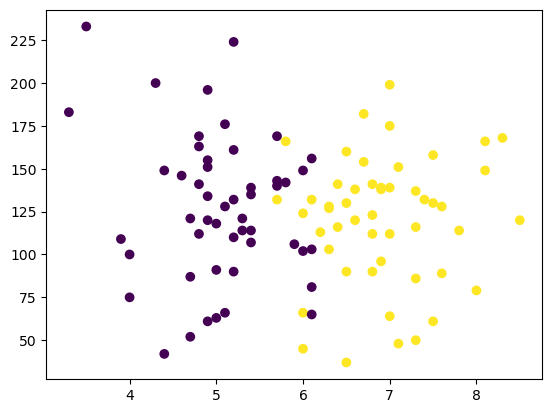

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y.shape

(100,)

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [15]:
X_train

,cgpa,iq
35,6.8,90.0
12,5.4,139.0
45,6.0,66.0
18,4.0,100.0
93,6.8,112.0
...,...,...
67,5.0,118.0
83,7.5,130.0
22,4.9,120.0
74,6.7,154.0


In [16]:
y_train

35    1
12    0
45    1
18    0
93    1
     ..
67    0
83    1
22    0
74    1
58    1
Name: placement, Length: 90, dtype: int64

In [17]:
X_test

,cgpa,iq
33,6.0,149.0
15,5.1,176.0
39,4.6,146.0
36,5.7,140.0
48,6.6,138.0
61,7.3,137.0
20,6.6,120.0
50,3.5,233.0
80,4.9,196.0
30,7.6,128.0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[ 6.98408275e-01, -7.73263271e-01],
       [-5.44521706e-01,  4.92076627e-01],
       [-1.18374284e-02, -1.39302159e+00],
       [-1.78745169e+00, -5.15030639e-01],
       [ 6.98408275e-01, -2.05151480e-01],
       [-1.18374284e-02,  1.04727679e-01],
       [ 8.75969701e-01,  1.42171410e+00],
       [ 4.32066136e-01, -7.73263271e-01],
       [-9.88425271e-01,  9.05248839e-01],
       [-1.43232884e+00,  7.50309259e-01],
       [-9.88425271e-01,  3.62960311e-01],
       [-1.07720598e+00,  5.43723153e-01],
       [ 9.64750414e-01, -1.85784033e+00],
       [-8.10863845e-01, -1.39302159e+00],
       [-1.89398854e-01,  5.69546417e-01],
       [ 2.20768040e+00,  1.43462573e-03],
       [-1.16598670e+00, -1.75454727e+00],
       [ 7.69432846e-02,  9.31072102e-01],
       [-7.22083132e-01,  2.68705400e+00],
       [ 2.54504710e-01,  1.82197468e-01],
       [-2.78179567e-01,  3.11313784e-01],
       [-1.07720598e+00,  1.26677452e+00],
       [-8.99644558e-01, -7.47440008e-01],
       [ 7.

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[-1.18374284e-02,  7.50309259e-01],
       [-8.10863845e-01,  1.44753737e+00],
       [-1.25476741e+00,  6.72839470e-01],
       [-2.78179567e-01,  5.17899890e-01],
       [ 5.20846849e-01,  4.66253364e-01],
       [ 1.14231184e+00,  4.40430101e-01],
       [ 5.20846849e-01,  1.43462573e-03],
       [-2.23135525e+00,  2.91946337e+00],
       [-9.88425271e-01,  1.96400263e+00],
       [ 1.40865398e+00,  2.08020732e-01]])

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [27]:
y_pred = clf.predict(X_test)

In [28]:
y_test

33    0
15    0
39    0
36    0
48    1
61    1
20    1
50    0
80    0
30    1
Name: placement, dtype: int64

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy_score(y_test,y_pred)

0.9

In [44]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

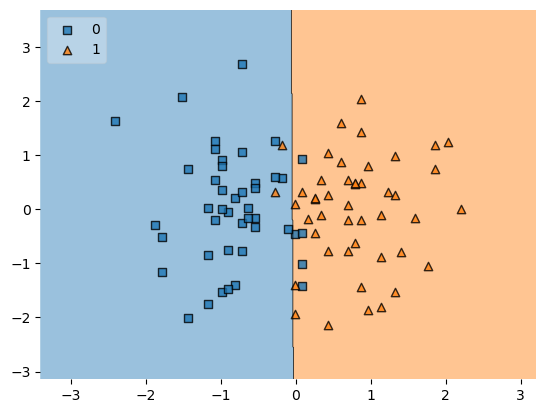

In [46]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [35]:
import pickle

In [36]:
pickle.dump(clf,open('model.pkl','wb'))